<a href="https://colab.research.google.com/github/liangliang6v6/Homeworks/blob/pages/Homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Task 1 (30 points): Implement a Decision Tree Classifier for your classification problem.
You may use a built-in package to implement your classifier. Additionally, do the following:
- Visualize the decision tree structure for at least three different parameter settings. Comment on how the depth and complexity change the tree.
- Do some research on what sensitivity analysis is and how it is performed (include citations). Perform a sensitivity analysis to measure the impact of at least two input features on your model's decision boundary.

##Answers
- The implementation and visualization are below. When the depth is low, the decision tree is shallow, with fewer splits and simpler rules. (tree1= decision_tree(max_depth=3, min_samples_split=2)), the model is simple to understand but might have an underfit problem or fail to capture the relationship in the dataset. However, if the depth is higher or it's the fully grown decision tree (tree2), it can capture the complex patterns in the dataset but might have an overfitting problem. The robustness of the model could be low. The complexity is controlled by the parameter "min_samples_split," the larger number indicates small splits and a simple tree. When the decision the tree is simpler; the generalization is better. With more splits, the complex tree might encounter an overfit problem.
- Sensitivity analysis [1] evaluates the impact of changes in input features on a model's outputs or decision boundaries. It helps identify which features are most influential in driving the model's predictions, thereby improving interpretability and robustness. For machine learning models [2], sensitivity analysis can be performed locally (varying one or two features while holding others constant) or globally (evaluating the combined impact of multiple features). By systematically varying selected input features, the model's predictions can be analyzed to understand how they change across the feature space. For instance, heatmaps or contour plots are often used to visualize decision boundaries and highlight feature interactions. This process provides critical insights into the role of input features in shaping the model's behavior [3].

### Reference
[1]. Saltelli, A. Global Sensitivity Analysis: the Primer. John Wiley & Sons, 2008.

[2]. Cukier, R. I., H. B. Levine, and K. E. Shuler. "Nonlinear sensitivity analysis of multiparameter model systems." Journal of computational physics 26.1 (1978): 1-42.

[3]. Razavi, Saman, et al. "The future of sensitivity analysis: an essential discipline for systems modeling and policy support." Environmental Modelling & Software 137 (2021): 104954.

Path to dataset files: /root/.cache/kagglehub/datasets/uciml/red-wine-quality-cortez-et-al-2009/versions/2
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978 

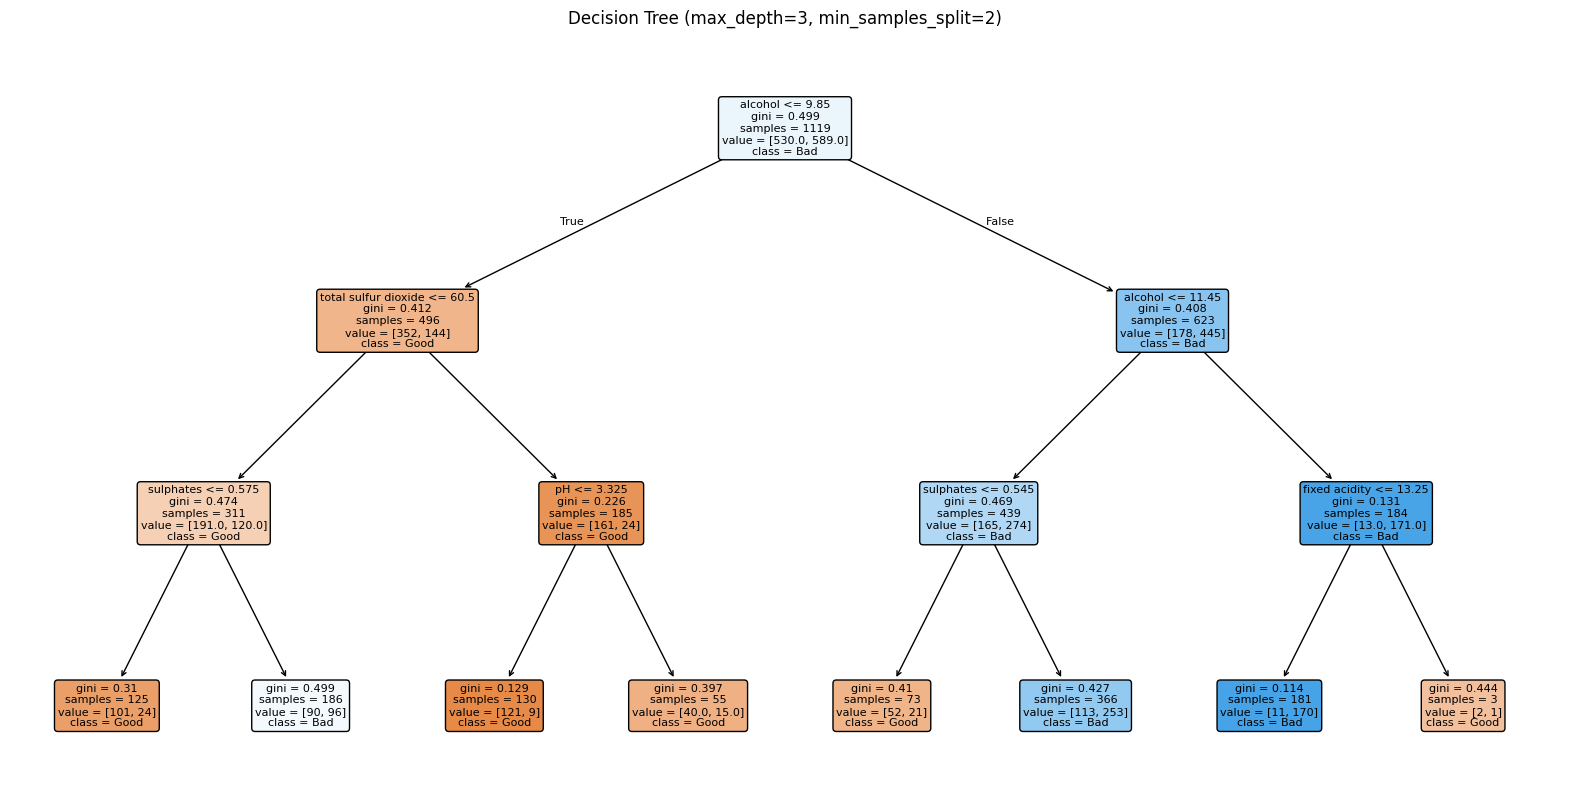

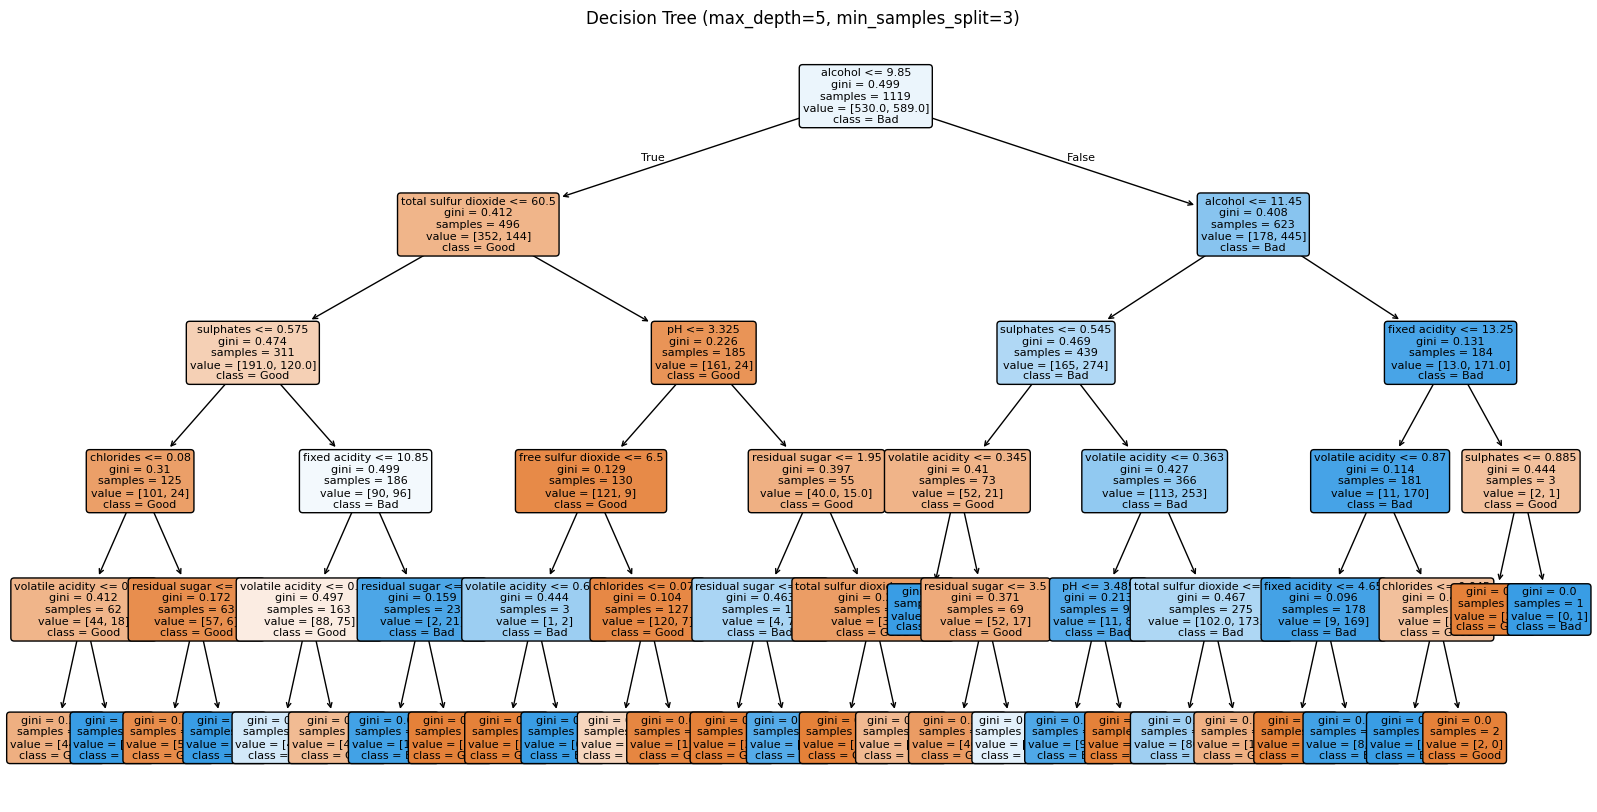

In [3]:
""" The financial dataset is too imbalance for negative pre, change for wine rate datsets"""
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# train use decision tree
def decision_tree(max_depth, min_samples_split, random_state=42):
  clf = DecisionTreeClassifier(max_depth = max_depth, min_samples_split=min_samples_split, random_state=random_state)
  clf.fit(X_train, y_train)
  plt.figure(figsize=(20, 10))
  plot_tree(clf, feature_names=X.columns, class_names=["Good", "Bad"], filled=True,rounded=True, fontsize=8)
  plt.title(f"Decision Tree (max_depth={max_depth}, min_samples_split={min_samples_split})")
  plt.show()
  return clf

# download latest version from kaggle
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

print("Path to dataset files:", path)
df = pd.read_csv(path+"/winequality-red.csv")
df['goodquality'] = [1 if x>=6 else 0 for x in df['quality']]
df.head()

X = df.drop(['quality','goodquality'],axis=1)
y = df['goodquality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

# complexity change comparison
tree1 = decision_tree(max_depth=3, min_samples_split=2)
tree2 = decision_tree(max_depth=5, min_samples_split=3)

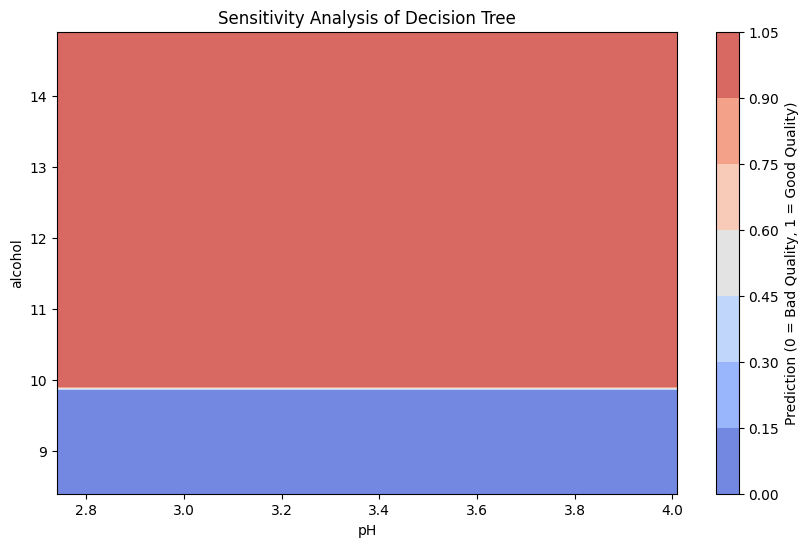

In [26]:
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import partial_dependence

# use balanced data to find the boundary
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

feature1, feature2 = 'pH', 'alcohol'
f1_range = np.linspace(X[feature1].min(), X[feature1].max(), 100)
f2_range = np.linspace(X[feature2].min(), X[feature2].max(), 100)
f1_grid, f2_grid = np.meshgrid(f1_range, f2_range)

X_fixed = X.median().to_frame().T
X_sensitivity = pd.DataFrame({
    feature1: f1_grid.ravel(),
    feature2: f2_grid.ravel(),
})
for col in X.columns:
    if col not in [feature1, feature2]:
        X_sensitivity[col] = X_fixed[col].values[0]

X_sensitivity = X_sensitivity[X_train.columns]


predictions = clf.predict(X_sensitivity).reshape(f1_grid.shape)

plt.figure(figsize=(10, 6))
plt.contourf(f1_grid, f2_grid, predictions, alpha=0.8, cmap='coolwarm')
plt.colorbar(label='Prediction (0 = Bad Quality, 1 = Good Quality)')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Sensitivity Analysis of Decision Tree')
plt.show()

##Task 2 (30 points): From the Bagging and Boosting ensemble methods pick any one algorithm from each category.
Implement both the algorithms using the same data.
- Use stratified k-fold cross-validation with at least three different folds (e.g., 5, 10, 15). You may do your own research on this technique (include citations).
- Evaluate the models using any three-evaluation metrics of your choice (e.g. accuracy, Precision, F1-score etc.).
- Comment on the behavior of each algorithm under the metrics. Does the performance ranking change based on the metric used? Why?

##Comments
- Bagging shows consistently better performance across all metrics and fold settings compared to Boosting. Its accuracy ranges from 81.41% to 83.74%, demonstrating its ability to generalize well across the dataset. The ensemble nature of Random Forest reduces variance by aggregating predictions from multiple decision trees, resulting in higher stability and reliability, particularly in datasets with moderate complexity. Additionally, its precision (83.14%–85.18%) indicates strong performance in minimizing false positives, while the F1-score (82.25%–84.49%) reflects a balanced trade-off between precision and recall. The slight variation in metrics across folds suggests it is resilient to data splits, consistently maintaining top-tier performance.
- Boosting achieves slightly lower scores across all metrics compared to Bagging, with accuracy ranging from 78.37% to 78.73%. This difference may arise from its iterative learning process, which focuses on correcting misclassified instances and is more prone to overfitting on specific folds. While its precision (79.48%–79.88%) and F1-score (79.58%–79.85%) are competitive, they lag behind Bagging. The performance gap suggests that while Boosting excels at improving bias in challenging datasets, its reliance on weak learners and iterative corrections may lead to less robust generalization when folds vary. Overall, Boosting performs consistently, but Bagging's stronger variance reduction gives it an edge across metrics.

In [27]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, f1_score
import numpy as np

# use the random forest as a Bagging method. Gradient boosting as a boosting method
bagging_model = RandomForestClassifier(n_estimators=100, random_state=42)
boosting_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

folds = [5, 10, 15]
results = {}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'f1': make_scorer(f1_score)
}

for fold in folds:
    skf = StratifiedKFold(n_splits=fold, shuffle=True, random_state=42)
    # check random forest
    bagging_scores = {}
    for metric, scorer in scoring.items():
        scores = cross_val_score(bagging_model, X_train, y_train, cv=skf, scoring=scorer)
        bagging_scores[metric] = np.mean(scores)
    results[f'Bagging (Random Forest) {fold} Folds'] = bagging_scores

    # check gradient boosting
    boosting_scores = {}
    for metric, scorer in scoring.items():
        scores = cross_val_score(boosting_model, X_train, y_train, cv=skf, scoring=scorer)
        boosting_scores[metric] = np.mean(scores)
    results[f'Boosting (Gradient Boosting) {fold} Folds'] = boosting_scores

# fianl results
for model, scores in results.items():
    print(f"\n{model}:")
    for metric, score in scores.items():
        print(f"  {metric.capitalize()}: {score:.4f}")


Bagging (Random Forest) 5 Folds:
  Accuracy: 0.8141
  Precision: 0.8314
  F1: 0.8225

Boosting (Gradient Boosting) 5 Folds:
  Accuracy: 0.7873
  Precision: 0.7988
  F1: 0.7985

Bagging (Random Forest) 10 Folds:
  Accuracy: 0.8374
  Precision: 0.8518
  F1: 0.8449

Boosting (Gradient Boosting) 10 Folds:
  Accuracy: 0.7847
  Precision: 0.7985
  F1: 0.7958

Bagging (Random Forest) 15 Folds:
  Accuracy: 0.8213
  Precision: 0.8330
  F1: 0.8309

Boosting (Gradient Boosting) 15 Folds:
  Accuracy: 0.7837
  Precision: 0.7948
  F1: 0.7962


##Task 3 (40 points): Compare the effectiveness of the three models implemented above. Analyze the results using the following:
- A confusion matrix for one selected test fold.
- A statistical test (e.g., paired t-test) to determine if differences between models are
significant.
- A discussion on the trade-off between bias and variance for each model.

##Discussion
- Based on the paired t-test results, we can observe that there are no statistically significant differences between the models. The p-values for all pairwise comparisons (Decision Tree vs Bagging: 0.1483, Bagging vs Boosting: 0.1249, and Decision Tree vs Boosting: 0.3786) are all above the typical significance threshold of 0.05, indicating that the differences in performance between these models are not statistically meaningful.
- Despite these findings, the Decision Tree generally has higher bias and lower variance, making it simpler but potentially less accurate. Bagging (Random Forest) provides a good balance between bias and variance, reducing the model's variance significantly and improving its generalization ability. Boosting (Gradient Boosting), with its focus on reducing bias through iterative correction, has slightly lower bias but can increase variance, particularly when overfitting occurs. Thus, while these models perform similarly in terms of overall accuracy, their behavior in terms of bias-variance trade-off differs, with Random Forest often offering the best generalization, while Gradient Boosting excels in capturing complex patterns at the risk of overfitting.

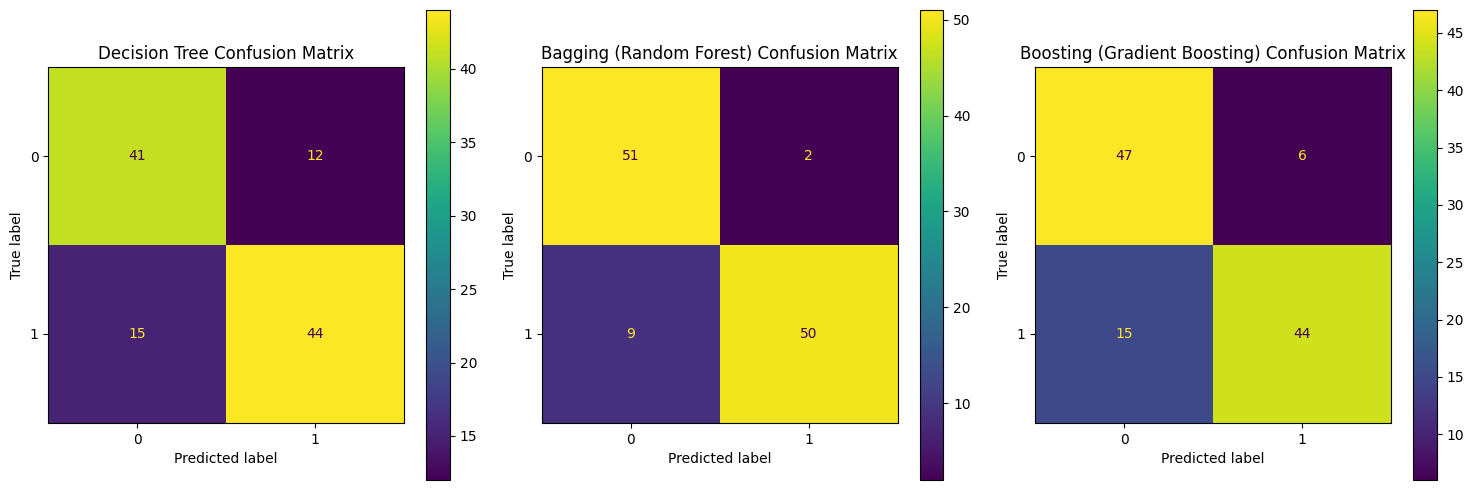

Decision Tree vs Bagging (Random Forest):
t-statistic: -1.5810, p-value: 0.1483
Bagging (Random Forest) vs Boosting (Gradient Boosting):
t-statistic: 1.6919, p-value: 0.1249
Decision Tree vs Boosting (Gradient Boosting):
t-statistic: -0.9260, p-value: 0.3786


In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import ttest_rel

dt_clf = DecisionTreeClassifier(max_depth=2, random_state=42)

"""A confusion matrix for one selected test fold."""

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
train_idx, test_idx = next(skf.split(X_train, y_train))
# train
dt_clf.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
bagging_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
boosting_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])

# test
dt_preds = dt_clf.predict(X_train.iloc[test_idx])
bagging_preds = bagging_model.predict(X_train.iloc[test_idx])
boosting_preds = boosting_model.predict(X_train.iloc[test_idx])

#confusion
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ConfusionMatrixDisplay.from_predictions(y_train.iloc[test_idx], dt_preds, ax=axes[0])
axes[0].set_title("Decision Tree Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_train.iloc[test_idx], bagging_preds, ax=axes[1])
axes[1].set_title("Bagging (Random Forest) Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_train.iloc[test_idx], boosting_preds, ax=axes[2])
axes[2].set_title("Boosting (Gradient Boosting) Confusion Matrix")
plt.tight_layout()
plt.show()

"""A statistical test (e.g., paired t-test) to determine if differences between models are significant."""
dt_scores = cross_val_score(dt_clf, X_train, y_train, cv=10, scoring="accuracy")
bagging_scores = cross_val_score(bagging_model, X_train, y_train, cv=10, scoring="accuracy")
boosting_scores = cross_val_score(boosting_model, X_train, y_train, cv=10, scoring="accuracy")

# perform paired t-tests
print("Decision Tree vs Bagging (Random Forest):")
t_stat, p_value = ttest_rel(dt_scores, bagging_scores)
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")

print("Bagging (Random Forest) vs Boosting (Gradient Boosting):")
t_stat, p_value = ttest_rel(bagging_scores, boosting_scores)
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")

print("Decision Tree vs Boosting (Gradient Boosting):")
t_stat, p_value = ttest_rel(dt_scores, boosting_scores)
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")


##Task (50 points): For the same classification problem solved above, implement the XGBoost algorithm.
If you picked XGBoost as one of the boosting algorithms in task 2, you may use the same implementation. Implement and evaluate XGBoost with the following requirements:
1. Perform a grid search or random search over at least 3 hyperparameters, such as learning rate, max depth, and subsample.
2. Analyze the sensitivity of your model to changes in these parameters.
3. Optional (no points taken off if not done) - Create plots to show the effect of each
parameter on accuracy and another metric.

##Analysis
- Based on the figures, learning rate and subsample exhibit fluctuations in performance, suggesting a high sensitivity to these parameters and the need for careful tuning to find a stable balance. For max_depth, performance drops significantly at a depth of 5, then improves slightly for deeper trees but remains lower than the initial peak, indicating overfitting at deeper levels. Lastly, the number of estimators shows that accuracy improves steadily up to around 100 trees, after which performance declines sharply, likely due to overfitting as more trees are added. These insights emphasize the importance of fine-tuning each parameter within specific ranges to optimize model performance.

In [3]:
!pip uninstall -y imbalanced-learn
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.3.1

Found existing installation: imbalanced-learn 0.13.0
Uninstalling imbalanced-learn-0.13.0:
  Successfully uninstalled imbalanced-learn-0.13.0
Found existing installation: scikit-learn 1.3.1
Uninstalling scikit-learn-1.3.1:
  Successfully uninstalled scikit-learn-1.3.1
  Using cached scikit_learn-1.3.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.3.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.9 MB)


In [8]:
import xgboost as xgb
# need scikit-learn==1.3.1
from sklearn.model_selection import RandomizedSearchCV
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

print("Path to dataset files:", path)
df = pd.read_csv(path+"/winequality-red.csv")
df['goodquality'] = [1 if x>=6 else 0 for x in df['quality']]
df.head()

X = df.drop(['quality','goodquality'],axis=1)
y = df['goodquality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)


Path to dataset files: /root/.cache/kagglehub/datasets/uciml/red-wine-quality-cortez-et-al-2009/versions/2


Best parameters: {'subsample': 0.6, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.052222222222222225}
Best score: 0.7175888853299167


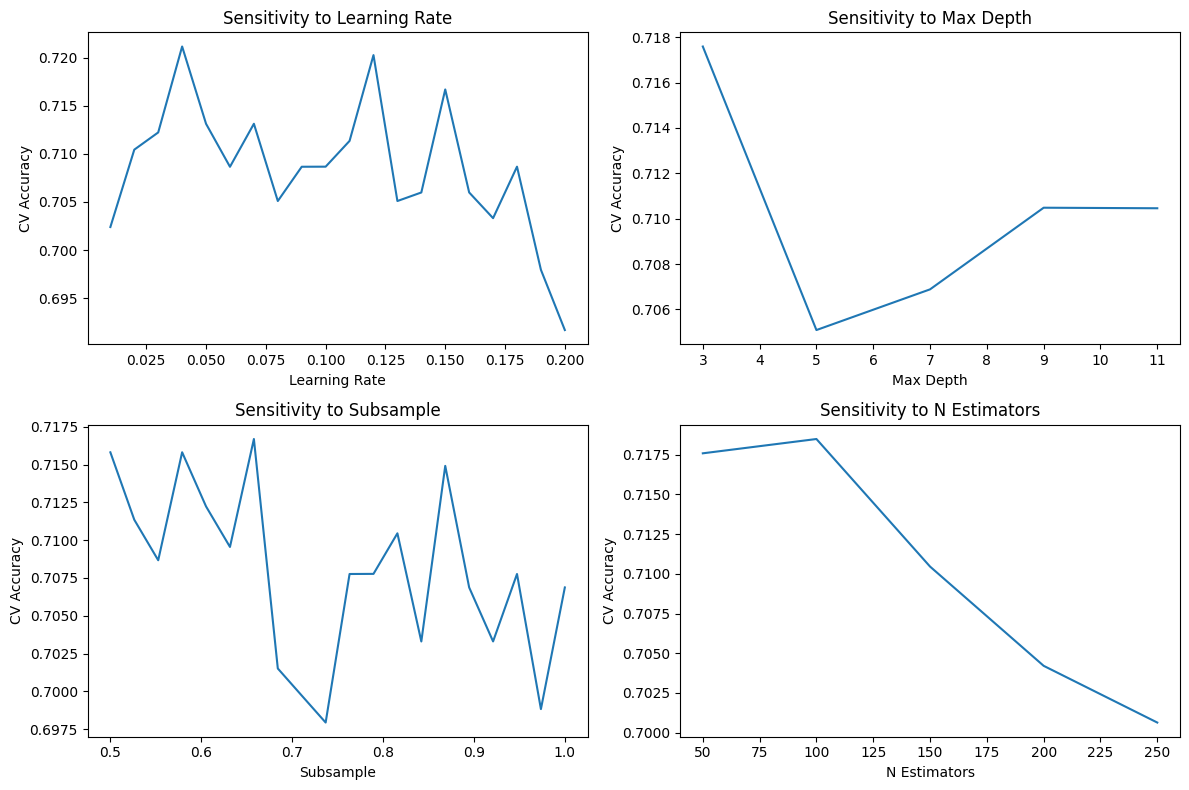

In [9]:
xgboost_model = xgb.XGBClassifier(random_state=42)

# hyperparameter search space
param_dist = {
    'learning_rate': np.linspace(0.01, 0.2, 10),
    'max_depth': [3, 5, 7, 10],
    'subsample': np.linspace(0.5, 1.0, 6),
    'n_estimators': [50, 100, 200],
}
random_search = RandomizedSearchCV(estimator=xgboost_model, param_distributions=param_dist, n_iter=50, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)

# analysis the sensitivity
def sens(param_name, param_range, model, X, y):
    scores = []
    for value in param_range:
        temp_params = random_search.best_params_.copy()
        temp_params[param_name] = value
        model.set_params(**temp_params)
        cv_score = np.mean(cross_val_score(model, X, y, cv=5, scoring='accuracy'))
        scores.append(cv_score)
    return scores
learning_rate_range = np.linspace(0.01, 0.2, 20)
max_depth_range = [3, 5, 7, 9, 11]
subsample_range = np.linspace(0.5, 1.0, 20)
n_estimators_range = [50, 100, 150, 200, 250]

learning_rate_scores = sens('learning_rate', learning_rate_range, xgboost_model, X_train, y_train)
max_depth_scores = sens('max_depth', max_depth_range, xgboost_model, X_train, y_train)
subsample_scores = sens('subsample', subsample_range, xgboost_model, X_train, y_train)
n_estimators_scores = sens('n_estimators', n_estimators_range, xgboost_model, X_train, y_train)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(learning_rate_range, learning_rate_scores)
plt.title('Sensitivity to Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('CV Accuracy')

plt.subplot(2, 2, 2)
plt.plot(max_depth_range, max_depth_scores)
plt.title('Sensitivity to Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('CV Accuracy')

plt.subplot(2, 2, 3)
plt.plot(subsample_range, subsample_scores)
plt.title('Sensitivity to Subsample')
plt.xlabel('Subsample')
plt.ylabel('CV Accuracy')

plt.subplot(2, 2, 4)
plt.plot(n_estimators_range, n_estimators_scores)
plt.title('Sensitivity to N Estimators')
plt.xlabel('N Estimators')
plt.ylabel('CV Accuracy')

plt.tight_layout()
plt.show()


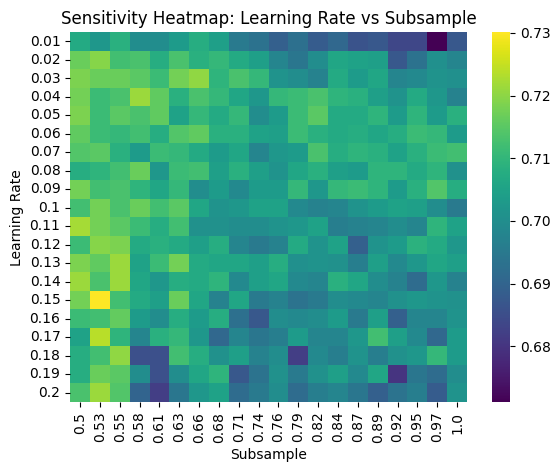

In [10]:
import seaborn as sns

heatmap_scores = []
for lr in learning_rate_range:
    row = []
    for ss in subsample_range:
        temp_params = random_search.best_params_.copy()
        temp_params['learning_rate'] = lr
        temp_params['subsample'] = ss
        xgboost_model.set_params(**temp_params)
        score = np.mean(cross_val_score(xgboost_model, X_train, y_train, cv=5, scoring='accuracy'))
        row.append(score)
    heatmap_scores.append(row)

sns.heatmap(heatmap_scores, xticklabels=subsample_range.round(2), yticklabels=learning_rate_range.round(2), cmap="viridis")
plt.title("Sensitivity Heatmap: Learning Rate vs Subsample")
plt.xlabel("Subsample")
plt.ylabel("Learning Rate")
plt.show()